# Customer Segmentation: KMeans Clustering Analysis

In [14]:
import sys
from pathlib import Path

# Add src to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


from utils import setup_logger, get_project_paths, ensure_path_exists

# Setup
logger = setup_logger(__name__)
paths = get_project_paths()
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

logger.info("Segmentation Pipeline Starting")

2026-04-18 21:52:44 - __main__ - INFO - Segmentation Pipeline Starting
2026-04-18 21:52:44 - __main__ - INFO - Segmentation Pipeline Starting
2026-04-18 21:52:44 - __main__ - INFO - Segmentation Pipeline Starting


## Step 1: Load and Prepare Data

In [5]:
X_seg = np.load(r"D:\Projects\TakeHomeProject\data\processed\Segmentation.npy")
X_seg_df = pd.read_csv(r"D:\Projects\TakeHomeProject\data\processed\Segmentation_data.csv")

## Step 2: Determine Optimal Number of Clusters (Elbow Method using PCA)

In [ ]:
pca_full = PCA(random_state=2401)
pca_full.fit(X_seg)

PCA(random_state=2401)

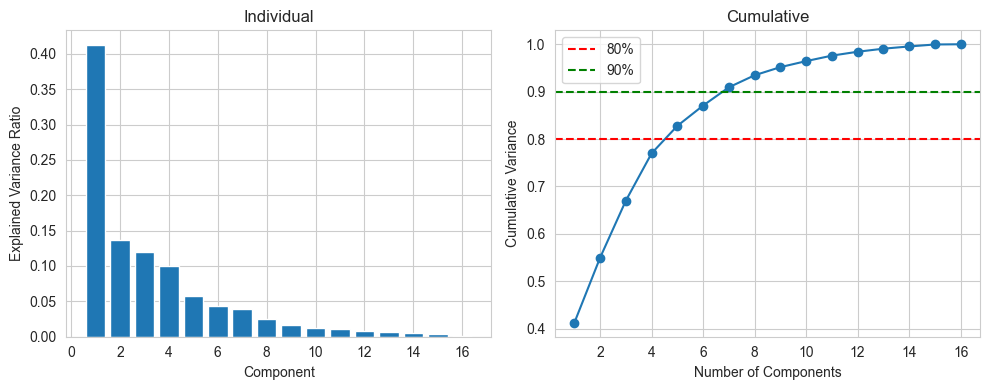

In [ ]:
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained)+1), explained)
plt.xlabel('Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Individual')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative)+1), cumulative, marker='o')
plt.axhline(0.80, color='r', linestyle='--', label='80%')
plt.axhline(0.90, color='g', linestyle='--', label='90%')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.title('Cumulative')
plt.legend()
plt.tight_layout()
plt.show()

We can see a elbow at 7

In [9]:
for threshold in [0.70, 0.80, 0.85, 0.90]:
    n = np.argmax(cumulative >= threshold) + 1
    print(f"{threshold:.0%} variance explained by {n} components")

70% variance explained by 4 components
80% variance explained by 5 components
85% variance explained by 6 components
90% variance explained by 7 components


In [10]:
pca = PCA(n_components=7, random_state=2401)
X_pca = pca.fit_transform(X_seg)
print(f"PCA shape: {X_pca.shape}")

PCA shape: (199523, 7)


## Step 3: Train KMeans Model

In [11]:
from sklearn.cluster import KMeans

inertias = []
k_range  = range(2, 12)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)
    print(f"k={k}  inertia={km.inertia_:.0f}")

d:\Projects\TakeHomeProject\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\Projects\TakeHomeProject\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__q

k=2  inertia=1865293
k=3  inertia=1444620
k=4  inertia=1071751
k=5  inertia=807527
k=6  inertia=662772
k=7  inertia=578035
k=8  inertia=515158
k=9  inertia=462365
k=10  inertia=411415
k=11  inertia=378342


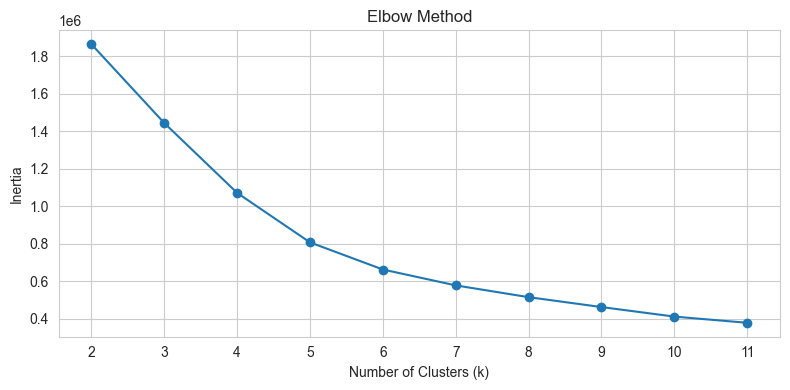

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

## Step 4: Cluster Profiling and Characterization

In [13]:
decreases = [inertias[i-1] - inertias[i] for i in range(1, len(inertias))]
for i, d in enumerate(decreases):
    print(f"k={i+2} → k={i+3}:  drop={d:,.0f}")

k=2 → k=3:  drop=420,673
k=3 → k=4:  drop=372,869
k=4 → k=5:  drop=264,224
k=5 → k=6:  drop=144,755
k=6 → k=7:  drop=84,737
k=7 → k=8:  drop=62,876
k=8 → k=9:  drop=52,793
k=9 → k=10:  drop=50,950
k=10 → k=11:  drop=33,074


k=5 → rate of drop slows noticeably after here

k=6 → reasonable option, one more meaningful split

k=7 → marginal gain, adds complexity




Retail marketing context: fewer segments = more actionable

5-6 segments is ideal — a marketing team can build

campaigns around 5-6 distinct customer profiles

In [15]:
for k in [4, 5, 6, 7]:
    km   = KMeans(n_clusters=k, random_state=42, n_init=10)
    labs = km.fit_predict(X_pca)
    sil  = silhouette_score(X_pca, labs, sample_size=10000, random_state=42)
    print(f"k={k}  silhouette={sil:.4f}")

k=4  silhouette=0.4654
k=5  silhouette=0.4992
k=6  silhouette=0.5247
k=7  silhouette=0.5155


k=4  → 0.4654  too coarse

k=5  → 0.4992  decent

k=6  → 0.5247  ← highest silhouette + elbow slowing here

k=7  → 0.5155  drops back down → k=6 is the sweet spot

We need to move the number of clusters from 7 to 6

In [16]:
km_final = KMeans(n_clusters=6, random_state=42, n_init=10)

Cluster distribution:
0    39012
1    58551
2    60558
3     7379
4    18319
5    15704
Name: count, dtype: int64


In [17]:
clusters = km_final.fit_predict(X_pca)
print(f"Cluster distribution:\n{pd.Series(clusters).value_counts().sort_index()}")

Cluster distribution:
0    39012
1    58551
2    60558
3     7379
4    18319
5    15704
Name: count, dtype: int64


In [26]:
X_seg_df['cluster'] = clusters

In [22]:
print(X_seg_df['cluster'].value_counts().sort_index())

cluster
0    39012
1    58551
2    60558
3     7379
4    18319
5    15704
Name: count, dtype: int64


In [23]:
X_seg_df = pd.read_csv("D:\Projects\TakeHomeProject\data\processed\Segmented_Data_Target.csv")

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Shreejit\AppData\Local\Temp\ipykernel_18372\2779021302.py:1: SyntaxWarning: invalid escape sequence '\P'
  X_seg_df = pd.read_csv("D:\Projects\TakeHomeProject\data\processed\Segmented_Data_Target.csv")


In [24]:
X_seg_df['label'].value_counts()

label
0    187141
1     12382
Name: count, dtype: int64

In [27]:
summary = X_seg_df.groupby('cluster').agg(
    size =('cluster', 'count'),
    pct_of_data =('cluster', lambda x: round(len(x)/len(X_seg_df)*100, 2)),
    pct_over_50k=('label', lambda x: round((x != 0).mean() * 100, 2))
).reset_index()

print(summary)

   cluster   size  pct_of_data  pct_over_50k
0        0  39012        19.55          0.71
1        1  58551        29.35          0.00
2        2  60558        30.35          7.57
3        3   7379         3.70         32.69
4        4  18319         9.18         22.34
5        5  15704         7.87          6.48


### Cluster Income Summary

| Cluster | Population Share | High-Income Share (`>50k`) | Interpretation |
|---|---:|---:|---|
| Cluster 1 | 29.35% | 0.00% | Lowest earners, zero high income |
| Cluster 0 | 19.55% | 0.71% | Very low earners |
| Cluster 5 | 7.87% | 6.48% | Below average earners |
| Cluster 2 | 30.35% | 7.57% | Average earners, largest group |
| Cluster 4 | 9.18% | 22.34% | High earners |
| Cluster 3 | 3.70% | 32.69% | Highest earners, smallest group |

## Step 5: Business Insights and Marketing Recommendations

In [28]:
data = pd.read_csv("D:\Projects\TakeHomeProject\data\processed\Raw_Data.csv")

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Shreejit\AppData\Local\Temp\ipykernel_18372\575003035.py:1: SyntaxWarning: invalid escape sequence '\P'
  data = pd.read_csv("D:\Projects\TakeHomeProject\data\processed\Raw_Data.csv")


In [29]:
data_seg_raw = data[[
    'age', 'education', 'weeks worked in year',
    'capital gains', 'dividends from stocks',
    'family members under 18', 'own business or self employed',
    'marital stat', 'class of worker',
    'full or part time employment stat', 'tax filer stat',
    'detailed household summary in household', 'major occupation code',
]].copy()

data_seg_raw['cluster'] = clusters
data_seg_raw['label'] = data['label'].values

In [30]:
num_profile = data_seg_raw.groupby('cluster').agg({
    'age': 'mean',
    'weeks worked in year': 'mean',
    'capital gains': 'mean',
    'dividends from stocks': 'mean',
}).round(2)

print(num_profile)

           age  weeks worked in year  capital gains  dividends from stocks
cluster                                                                   
0        56.52                  2.68            0.0                   0.02
1         8.99                  0.86            0.0                   0.27
2        38.82                 47.34            0.0                   0.00
3        48.50                 39.46        11754.5                1028.07
4        50.02                 34.19            0.0                1736.16
5        33.51                 43.59            0.0                   0.29


In [31]:
cat_cols_raw = [
    'education', 'marital stat', 'class of worker',
    'full or part time employment stat', 'tax filer stat',
    'detailed household summary in household', 'major occupation code',
    'family members under 18'
]

cat_profile = data_seg_raw.groupby('cluster')[cat_cols_raw].agg(
    lambda x: x.mode()[0]
)
print(cat_profile)

                          education                     marital stat  \
cluster                                                                
0              High school graduate  Married-civilian spouse present   
1                          Children                    Never married   
2              High school graduate  Married-civilian spouse present   
3              High school graduate  Married-civilian spouse present   
4        Bachelors degree(BA AB BS)  Married-civilian spouse present   
5              High school graduate  Married-civilian spouse present   

         class of worker full or part time employment stat  \
cluster                                                      
0        Not in universe          Children or Armed Forces   
1        Not in universe          Children or Armed Forces   
2                Private          Children or Armed Forces   
3                Private          Children or Armed Forces   
4                Private          Children or Armed

In [32]:
cluster_names = {
    0: 'Retired / Elderly',
    1: 'Children / Dependents',
    2: 'Working Middle Class',
    3: 'High Earners',
    4: 'Wealthy Investors',
    5: 'Young Working Adults',
}

X_seg_df['segment'] = X_seg_df['cluster'].map(cluster_names)
data_seg_raw['segment'] = data_seg_raw['cluster'].map(cluster_names)

#### Income Rate by Segment

In [33]:
print(X_seg_df.groupby('segment')['label'].apply(
    lambda x: (x != 0).mean() * 100
).round(2).sort_values(ascending=False).rename('>50k %'))

segment
High Earners             32.69
Wealthy Investors        22.34
Working Middle Class      7.57
Young Working Adults      6.48
Retired / Elderly         0.71
Children / Dependents     0.00
Name: >50k %, dtype: float64


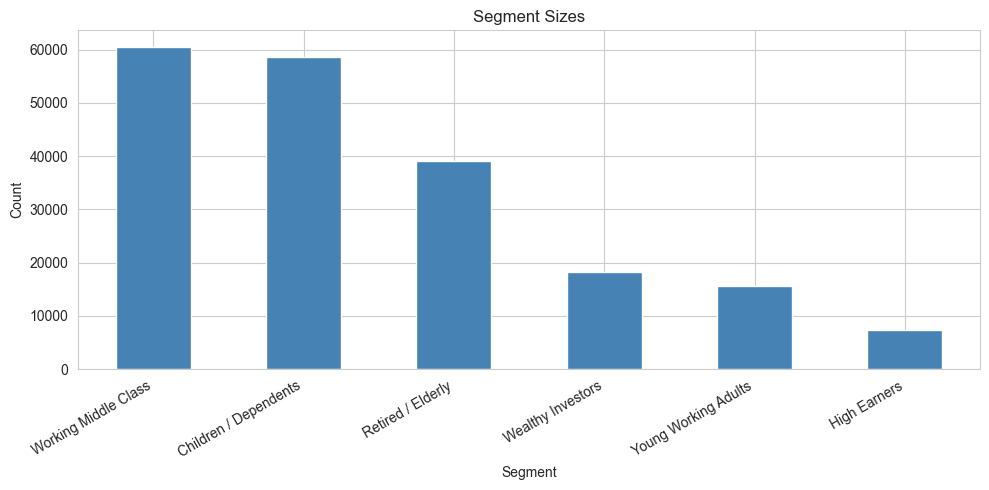

In [36]:
seg_counts = X_seg_df['segment'].value_counts()

plt.figure(figsize=(10, 5))
seg_counts.plot(kind='bar', color='steelblue')
plt.title('Segment Sizes')
plt.ylabel('Count')
plt.xlabel('Segment')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [37]:
marketing = {
    'Children / Dependents': 'Not a direct target — market to parents instead',
    'Retired / Elderly': 'Fixed income products, healthcare, leisure, comfort brands',
    'Working Middle Class': 'Everyday value, family products, mortgages, mid-range retail',
    'Young Working Adults': 'Career growth, tech, lifestyle brands, entry-level investments',
    'Wealthy Investors': 'Premium products, financial services, travel, luxury brands',
    'High Earners': 'Luxury retail, exclusive memberships, high-end financial products',
}

for seg, rec in marketing.items():
    size = seg_counts.get(seg, 0)
    pct  = size / len(X_seg_df) * 100
    print(f"\n{seg} ({pct:.1f}% of population)")
    print(f"  → {rec}")


Children / Dependents (29.3% of population)
  → Not a direct target — market to parents instead

Retired / Elderly (19.6% of population)
  → Fixed income products, healthcare, leisure, comfort brands

Working Middle Class (30.4% of population)
  → Everyday value, family products, mortgages, mid-range retail

Young Working Adults (7.9% of population)
  → Career growth, tech, lifestyle brands, entry-level investments

Wealthy Investors (9.2% of population)
  → Premium products, financial services, travel, luxury brands

High Earners (3.7% of population)
  → Luxury retail, exclusive memberships, high-end financial products


#### Final Visualization

In [43]:
seg_summary = X_seg_df.groupby('segment').agg(
    size        =('cluster', 'count'),
    pct_over_50k=('label', lambda x: (x != 0).mean() * 100)
).reset_index()
seg_summary['pct_of_pop'] = seg_summary['size'] / len(X_seg_df) * 100

seg_summary = seg_summary.sort_values('pct_over_50k', ascending=False)
print(seg_summary)

                 segment   size  pct_over_50k  pct_of_pop
1           High Earners   7379     32.687356    3.698320
3      Wealthy Investors  18319     22.337464    9.181398
4   Working Middle Class  60558      7.566300   30.351388
5   Young Working Adults  15704      6.482425    7.870772
2      Retired / Elderly  39012      0.710038   19.552633
0  Children / Dependents  58551      0.001708   29.345489


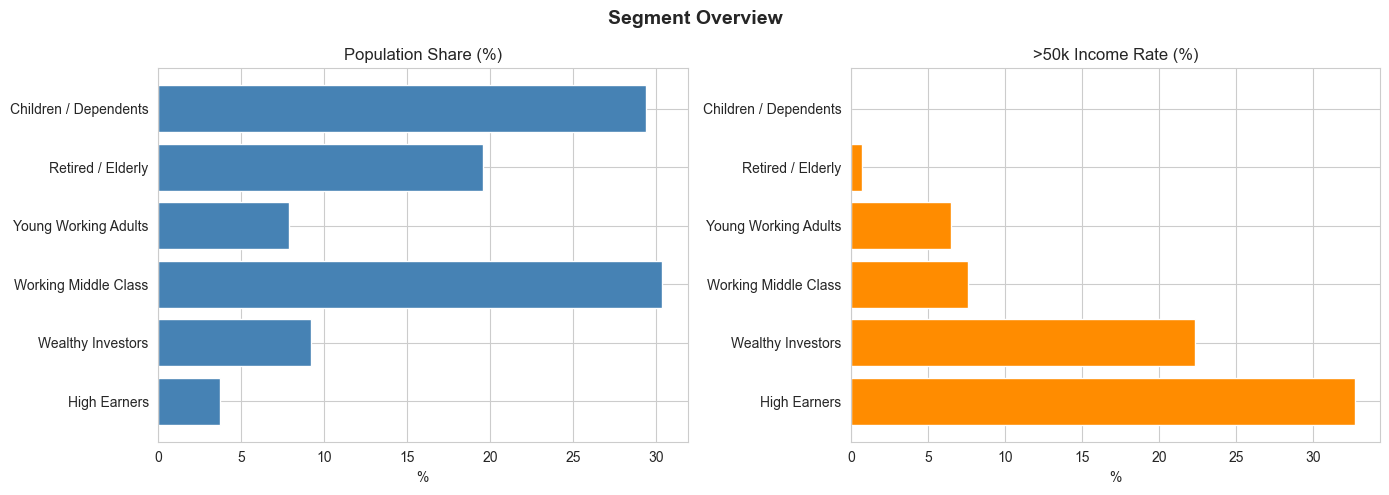

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(seg_summary['segment'], seg_summary['pct_of_pop'], color='steelblue')
axes[0].set_title('Population Share (%)')
axes[0].set_xlabel('%')

axes[1].barh(seg_summary['segment'], seg_summary['pct_over_50k'], color='darkorange')
axes[1].set_title('>50k Income Rate (%)')
axes[1].set_xlabel('%')

plt.suptitle('Segment Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

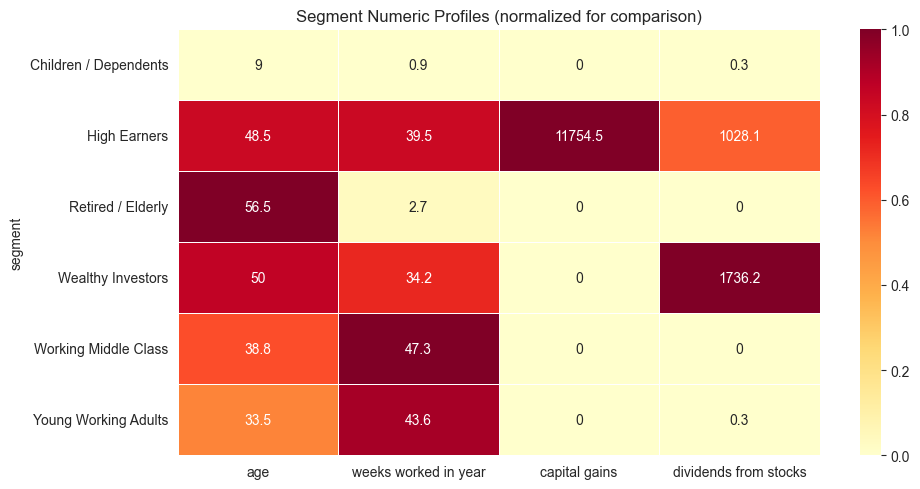

In [45]:
num_heatmap = data_seg_raw.groupby('segment').agg({
    'age':                   'mean',
    'weeks worked in year':  'mean',
    'capital gains':         'mean',
    'dividends from stocks': 'mean',
}).round(1)

num_heatmap_norm = (num_heatmap - num_heatmap.min()) / (num_heatmap.max() - num_heatmap.min())

plt.figure(figsize=(10, 5))
sns.heatmap(
    num_heatmap_norm,
    annot=num_heatmap,    
    fmt='g',
    cmap='YlOrRd',
    linewidths=0.5
)
plt.title('Segment Numeric Profiles (normalized for comparison)')
plt.tight_layout()
plt.show()

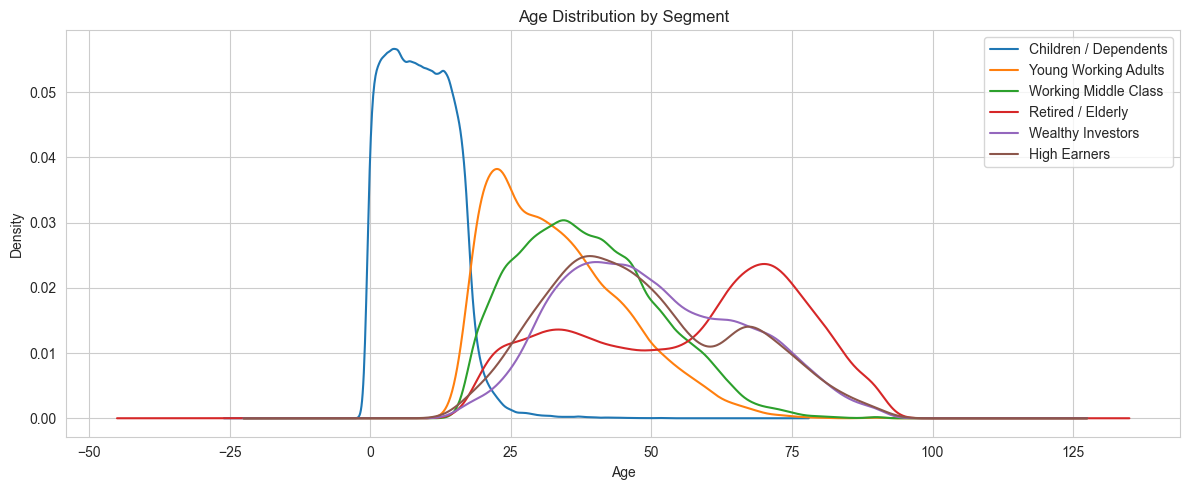

In [46]:
seg_order = [
    'Children / Dependents', 'Young Working Adults', 'Working Middle Class',
    'Retired / Elderly', 'Wealthy Investors', 'High Earners'
]

plt.figure(figsize=(12, 5))
for seg in seg_order:
    subset = data_seg_raw[data_seg_raw['segment'] == seg]['age']
    subset.plot(kind='kde', label=seg)

plt.title('Age Distribution by Segment')
plt.xlabel('Age')
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

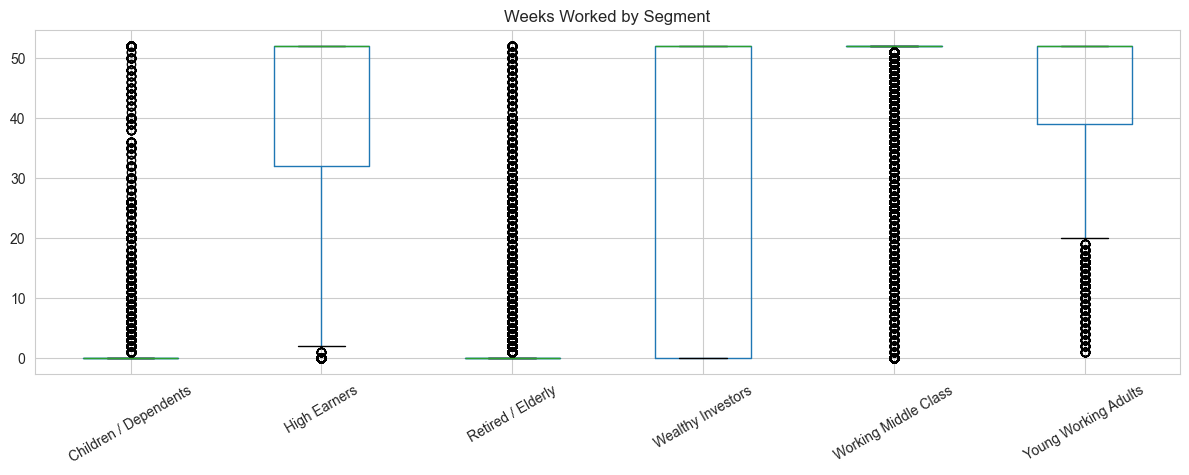

In [47]:
plt.figure(figsize=(12, 5))
data_seg_raw.boxplot(
    column='weeks worked in year',
    by='segment',
    figsize=(12, 5),
    rot=30
)
plt.title('Weeks Worked by Segment')
plt.suptitle('')
plt.xlabel('')
plt.tight_layout()
plt.show()

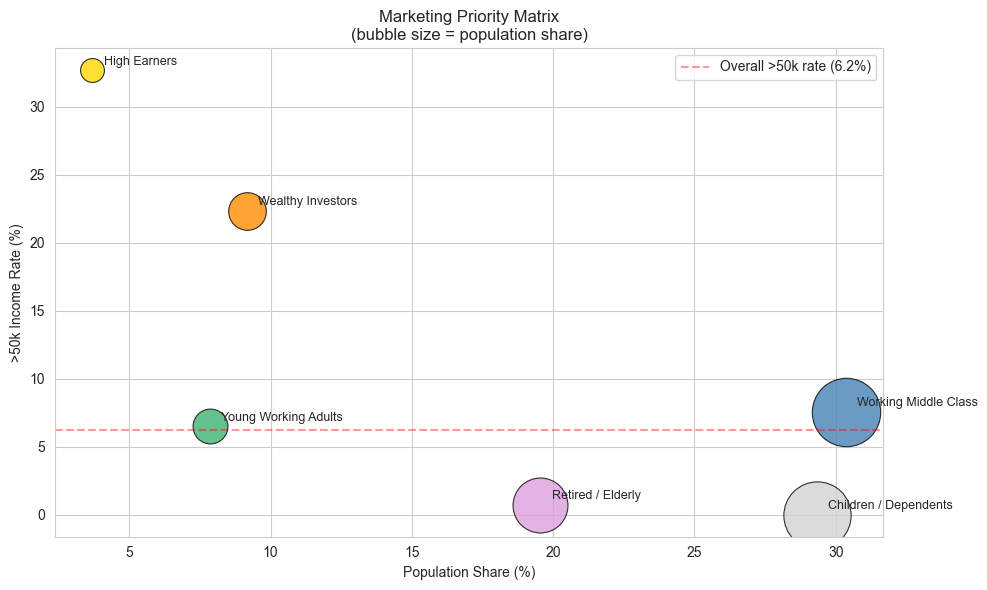

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    'High Earners': 'gold',
    'Wealthy Investors': 'darkorange',
    'Working Middle Class': 'steelblue',
    'Young Working Adults': 'mediumseagreen',
    'Retired / Elderly': 'plum',
    'Children / Dependents': 'lightgray',
}

for _, row in seg_summary.iterrows():
    seg  = row['segment']
    ax.scatter(
        row['pct_of_pop'],
        row['pct_over_50k'],
        s=row['pct_of_pop'] * 80,
        color=colors[seg],
        alpha=0.8,
        edgecolors='black',
        linewidths=0.8
    )
    ax.annotate(
        seg,
        (row['pct_of_pop'], row['pct_over_50k']),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=9
    )

ax.set_xlabel('Population Share (%)')
ax.set_ylabel('>50k Income Rate (%)')
ax.set_title('Marketing Priority Matrix\n(bubble size = population share)')
ax.axhline(6.2, color='red', linestyle='--', alpha=0.4, label='Overall >50k rate (6.2%)')
ax.legend()
plt.tight_layout()
plt.show()

## Step 6: Save Model and Results

In [49]:
# Save segmentation artifacts for reuse
from pathlib import Path

ensure_path_exists(paths['models'])
models_dir = paths['models']
processed_dir = Path(r"D:\Projects\TakeHomeProject\data\processed")
processed_dir.mkdir(parents=True, exist_ok=True)

# Models
joblib.dump(km_final, models_dir / 'kmeans_segmentation_model.joblib', compress=3)
joblib.dump(pca, models_dir / 'segmentation_pca_model.joblib', compress=3)

# Results
np.save(processed_dir / 'segmentation_X_pca.npy', X_pca)
seg_summary.to_csv(processed_dir / 'segmentation_summary.csv', index=False)

seg_assignments = data.copy()
if 'cluster' not in seg_assignments.columns:
    seg_assignments['cluster'] = clusters
if 'segment' not in seg_assignments.columns and 'cluster_names' in globals():
    seg_assignments['segment'] = seg_assignments['cluster'].map(cluster_names)
seg_assignments.to_pickle(processed_dir / 'segmentation_assignments.pkl')

print('Saved models:')
print(models_dir / 'kmeans_segmentation_model.joblib')
print(models_dir / 'segmentation_pca_model.joblib')
print('Saved results:')
print(processed_dir / 'segmentation_X_pca.npy')
print(processed_dir / 'segmentation_summary.csv')
print(processed_dir / 'segmentation_assignments.pkl')

Saved models:
d:\Projects\TakeHomeProject\outputs\models\kmeans_segmentation_model.joblib
d:\Projects\TakeHomeProject\outputs\models\segmentation_pca_model.joblib
Saved results:
D:\Projects\TakeHomeProject\data\processed\segmentation_X_pca.npy
D:\Projects\TakeHomeProject\data\processed\segmentation_summary.csv
D:\Projects\TakeHomeProject\data\processed\segmentation_assignments.pkl


Final Best Model: kmeans_segmentation_model.joblib

It has 6 clusters

- 0: 'Retired / Elderly'
- 1: 'Children / Dependents'
- 2: 'Working Middle Class'
- 3: 'High Earners'
- 4: 'Wealthy Investors'
- 5: 'Young Working Adults'